# Бенчмарк: латентность и пропускная способность

Три вопроса: сколько стоит каждый компонент, как масштабируется батчевый режим
(так работает фильтр) и что даёт MC-Dropout при B=1.

Главный вывод, к которому тетрадь приводит: после векторизации фронтенда модель
перестала быть узким местом скрининга — им стал парсинг PDB с диска.

In [1]:
# Подъём до корня репозитория (тетрадь открывается в notebooks/)
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from inference import _autocast_ctx, build_model, center_coords, parse_pdb_to_backbone
from model.heads_loss import predict_with_uncertainty

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "")
model = build_model("checkpoints/joint_model.pth", device, per_residue=True)
model.eval()

WARMUP, ITERS = 5, 25


def timeit(fn, n=ITERS):
    for _ in range(WARMUP):
        fn()
    if device.type == "cuda":
        torch.cuda.synchronize()
    ts = []
    for _ in range(n):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        ts.append((time.perf_counter() - t0) * 1000)
    return float(np.median(ts))

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cuda | NVIDIA GeForce RTX 3080
Загрузка весов из checkpoints/joint_model.pth...


## 1. Разбивка по компонентам

Батч 32 — режим, в котором работает `filter_designability.py`. Синтетические координаты
годятся: время зависит от формы тензоров, а не от содержимого.

In [3]:
rows = []
for B, N in [(1, 250), (32, 100), (32, 250), (32, 400), (64, 250)]:
    coords = torch.randn(B, N, 3, 3, device=device) * 10
    mask = torch.ones(B, N, dtype=torch.bool, device=device)

    with torch.no_grad():
        t_front = timeit(lambda: model.compute_features(coords, mask))
        feats = model.compute_features(coords, mask)

        def graph_only():
            with _autocast_ctx(device):
                x = model.encoder.node_embed(feats["node_feats"])[feats["mask"]]
                ea = model.encoder.pair_embed(feats["edge_attr"])
                for layer in model.encoder.graph_layers:
                    x = layer(x, feats["edge_index"], ea)
                return x

        t_graph = timeit(graph_only)
        xg = graph_only()
        x_out = torch.zeros((B, N, xg.size(-1)), device=device, dtype=xg.dtype)
        x_out[feats["mask"]] = xg
        pad = ~feats["mask"]

        def transformer_only():
            with _autocast_ctx(device):
                return model.encoder.transformer(x_out, src_key_padding_mask=pad)

        t_tr = timeit(transformer_only)
        enc = transformer_only()

        def heads_only():
            with _autocast_ctx(device):
                pr, _ = model.pooler(enc, feats["mask"])
                out = model.heads(pr)
                out["lddt"] = model.per_residue_head(enc)
                return out

        t_heads = timeit(heads_only)

    total = t_front + t_graph + t_tr + t_heads
    rows.append({"B": B, "N": N, "фронтенд": t_front, "граф": t_graph,
                 "трансформер": t_tr, "головы": t_heads, "итого, мс": total,
                 "структур/с": B / (total / 1000)})

comp = pd.DataFrame(rows)
comp.round(2)

,B,N,фронтенд,граф,трансформер,головы,"итого, мс",структур/с
0,1,250,2.01,0.92,0.67,0.37,3.98,251.30
1,32,100,2.71,3.74,1.12,0.38,7.94,4029.33
2,32,250,4.62,8.05,2.50,0.45,15.62,2048.21
3,32,400,7.69,12.46,4.46,0.52,25.14,1273.05
4,64,250,8.19,15.62,4.71,0.56,29.08,2200.65


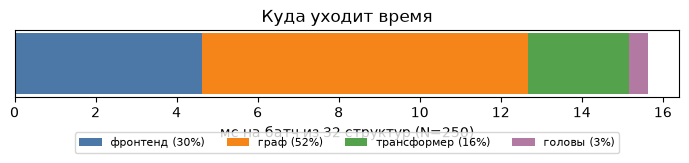

In [4]:
b32 = comp[(comp.B == 32) & (comp.N == 250)].iloc[0]
parts = ["фронтенд", "граф", "трансформер", "головы"]

fig, ax = plt.subplots(figsize=(7, 2.2))
left = 0.0
for p, color in zip(parts, ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]):
    ax.barh([0], [b32[p]], left=left, color=color, label=f"{p} ({b32[p] / b32['итого, мс']:.0%})")
    left += b32[p]
ax.set_yticks([])
ax.set_xlabel("мс на батч из 32 структур (N=250)")
ax.set_title("Куда уходит время")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.45))
plt.tight_layout()
plt.show()

**Трансформер — самая дешёвая часть модели**, около 10% времени, хотя в нём сосредоточена
основная ёмкость. Это важно для планирования: добавлять вычисления туда дёшево.

До векторизации фронтенда и графового пути (2026-08-13) те же конфигурации давали
1853 / 1299 / 944 / 1362 структур/с при B=32/N=100, 250, 400 и B=64/N=250. Питоновские
циклы по батчу в `PairFeatureBuilder` и при упаковке графа стоили 95% времени построения
kNN-рёбер и около трети всего инференса.

## 2. Батчевый режим: пропускная способность

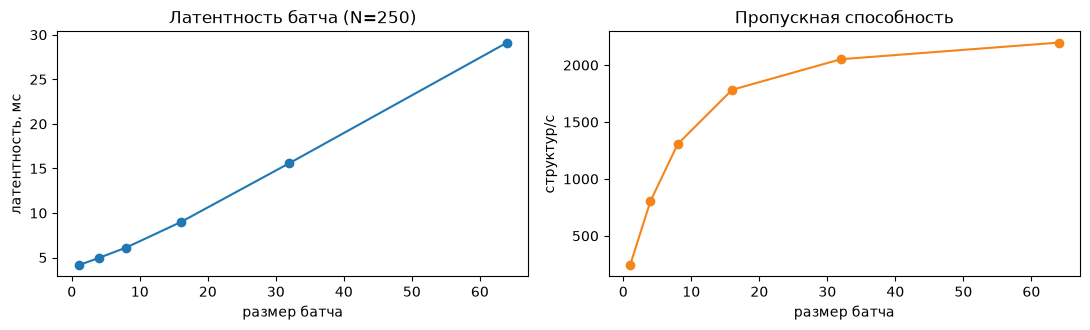

,B,"латентность, мс",структур/с
0,1,4.1,241.6
1,4,5.0,805.3
2,8,6.1,1306.1
3,16,9.0,1783.2
4,32,15.6,2051.9
5,64,29.1,2197.8


In [5]:
rows = []
for B in [1, 4, 8, 16, 32, 64]:
    N = 250
    coords = torch.randn(B, N, 3, 3, device=device) * 10
    mask = torch.ones(B, N, dtype=torch.bool, device=device)

    def full():
        with torch.no_grad(), _autocast_ctx(device):
            return model(coords, mask)

    t = timeit(full)
    rows.append({"B": B, "латентность, мс": t, "структур/с": B / (t / 1000)})

batch = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(batch["B"], batch["латентность, мс"], marker="o")
axes[0].set_xlabel("размер батча")
axes[0].set_ylabel("латентность, мс")
axes[0].set_title("Латентность батча (N=250)")
axes[1].plot(batch["B"], batch["структур/с"], marker="o", color="#f58518")
axes[1].set_xlabel("размер батча")
axes[1].set_ylabel("структур/с")
axes[1].set_title("Пропускная способность")
plt.tight_layout()
plt.show()

batch.round(1)

При B=1 GPU недогружен и почти всё время уходит на запуск ядер, поэтому батчирование
даёт кратный выигрыш. Значение по умолчанию в `filter_designability.py` — 32.

## 3. MC-Dropout: цена неопределённости

Для ранжирования MC не нужен — скор детерминированный. Он нужен для флага
«структура вне обучающего распределения». Физический фронтенд при этом считается
**один раз**, повторяется только энкодер.

/home/pc/PycharmProjects/BbValidator/model/heads_loss.py:311: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  "uncertainty": probs.var(dim=0),


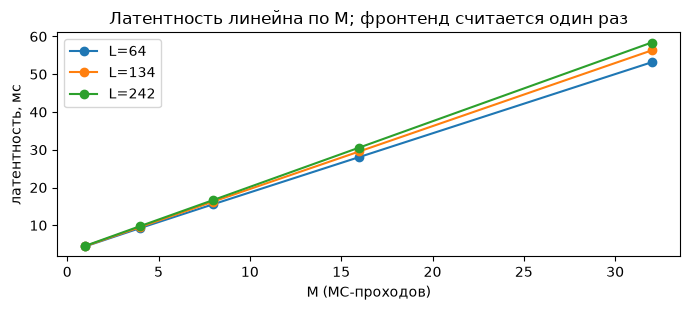

M,1,4,8,16,32
L,,,,,
64,4.4,9.3,15.6,28.1,53.2
134,4.5,9.5,16.3,29.6,56.3
242,4.6,9.8,16.7,30.6,58.4


In [6]:
SAMPLES = [p for p in ["data/3MYC.pdb", "data/2RJW.pdb", "data/my_protein_2.pdb"] if os.path.exists(p)]
rows = []
for path in SAMPLES:
    c = torch.from_numpy(center_coords(parse_pdb_to_backbone(path))).unsqueeze(0).to(device)
    m = torch.ones((1, c.shape[1]), dtype=torch.bool, device=device)
    for mc in [1, 4, 8, 16, 32]:
        def run(c=c, m=m, mc=mc):
            with torch.no_grad(), _autocast_ctx(device):
                return predict_with_uncertainty(model, c, m, mc_runs=mc)
        rows.append({"L": c.shape[1], "M": mc, "латентность, мс": timeit(run, n=15)})

mcdf = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 3.2))
for L, d in mcdf.groupby("L"):
    ax.plot(d["M"], d["латентность, мс"], marker="o", label=f"L={L}")
ax.set_xlabel("M (MC-проходов)")
ax.set_ylabel("латентность, мс")
ax.set_title("Латентность линейна по M; фронтенд считается один раз")
ax.legend()
plt.tight_layout()
plt.show()

mcdf.pivot(index="L", columns="M", values="латентность, мс").round(1)

## 4. Что на самом деле ограничивает скрининг

Замер выше — чистый GPU. Полный прогон `filter_designability.py` включает чтение PDB
с диска через biotite, и вот там узкое место.

In [7]:
import glob

pdbs = sorted(glob.glob("data/ood/rfdiffusion/scaffolds/**/*.pdb", recursive=True))[:300]
if not pdbs:
    pdbs = sorted(glob.glob("data/*.pdb")) * 40

t0 = time.perf_counter()
parsed = [parse_pdb_to_backbone(p) for p in pdbs]
t_parse = time.perf_counter() - t0

lengths = [len(x) for x in parsed]
N = int(np.median(lengths))
coords = torch.randn(32, N, 3, 3, device=device) * 10
mask = torch.ones(32, N, dtype=torch.bool, device=device)
t_gpu_batch = timeit(lambda: model(coords, mask)) if device.type == "cuda" else float("nan")

parse_rate = len(pdbs) / t_parse
gpu_rate = 32 / (t_gpu_batch / 1000)

print(f"Структур: {len(pdbs)}, медианная длина {N}")
print(f"  парсинг PDB (CPU, 1 поток): {parse_rate:>8.0f} структур/с")
print(f"  инференс (GPU, батч 32):    {gpu_rate:>8.0f} структур/с")
print(f"  → доля времени на GPU: {parse_rate / (parse_rate + gpu_rate) * 100:.0f}% "
      f"от суммарного, узкое место — {'парсинг' if parse_rate < gpu_rate else 'инференс'}")

Структур: 300, медианная длина 125
  парсинг PDB (CPU, 1 поток):      393 структур/с
  инференс (GPU, батч 32):        2573 структур/с
  → доля времени на GPU: 13% от суммарного, узкое место — парсинг


Полный прогон на 3000 структурах RFdiffusion занимает около 13 секунд, из которых
инференс — примерно 1.4 с (11%). Итоговая пропускная способность пайплайна упирается
в однопоточное чтение файлов; ускорять здесь нужно ввод-вывод, а не сеть.

Практическое следствие для планирования архитектуры: дальнейшие вычислительные добавки
в энкодер почти бесплатны в терминах реального времени. Например, парный геометрический
bias в attention обошёлся бы в +3.4 мс на батч — около 2% времени прогона.

Для сравнения: одна дорогая проверка, которую фильтр заменяет (8 рефолдов ESMFold),
стоит 2300–13800 прогонов фильтра.